In [1]:
# PDF 읽기 개념을 싼타페 779쪽 자료에 적용해 글·그림·출처를 조사합니다.
# 추가: PDF 쪽수와 인쇄 쪽수 구분, 사람이 확인한 그림 설명, raw_text 보존, 페이지별 이미지 경로 연결.
# [프로젝트 추가 기록] PDF 읽기 개념을 싼타페 779쪽 자료에 적용해 글·그림·출처를 조사합니다.
# 추가 이유·한계·수업 근거 전체 목록: src/zzong_santafe_lag/learning_additions.md
from pathlib import Path
from pypdf import PdfReader

# 현재 위치(notebooks)의 한 단계 위가 프로젝트 폴더입니다.
project_root = Path.cwd().parent

# 프로젝트 폴더 안의 data 폴더에서 PDF를 찾습니다.
pdf_path = project_root / "data" / "santafe_hev_manual.pdf"

# 경로가 맞는지 먼저 확인합니다.
print(f"찾는 위치: {pdf_path}")
print(f"파일이 있나요?: {pdf_path.exists()}")

찾는 위치: c:\mle-02-p1-team1\data\santafe_hev_manual.pdf
파일이 있나요?: True


In [2]:
# [프로젝트 추가 기록] PDF 읽기 개념을 싼타페 779쪽 자료에 적용해 글·그림·출처를 조사합니다.
# 추가 이유·한계·수업 근거 전체 목록: src/zzong_santafe_lag/learning_additions.md
from pypdf import PdfReader

# 확인한 경로의 PDF를 엽니다.
reader = PdfReader(str(pdf_path))

# PDF에 들어 있는 전체 페이지 수를 출력합니다.
print(f"전체 페이지 수: {len(reader.pages)}")

# 파이썬은 페이지를 0부터 세므로 [0]은 첫 페이지입니다.
first_page_text = reader.pages[0].extract_text() or ""

# 첫 페이지에서 추출한 글자 수와 앞부분을 확인합니다.
print(f"첫 페이지 글자 수: {len(first_page_text)}자")
print("\n[첫 페이지 글자 앞부분]")
print(first_page_text[:500])

전체 페이지 수: 779
첫 페이지 글자 수: 414자

[첫 페이지 글자 앞부분]
안전 및 차량 손상 경고
본 취급설명서에는 고객 및 차량의 안전을 위해 유의해야 할 사항과 제품 사용에 대한 정확한 정보
를 알리는 안전경고 표시가 포함되어 있습니다. 지시사항을 반드시 숙지하고 준수하십시오.
경고, 주의표시 경고, 주의가 있는 문장 및 진하게 표시되어 있는 부분은 특히 유념하
십시오.
҃Ҋ 
부상이나 사망의 우려가 있는 경우를 나타내는 표시입니다.
 ઱੄ 
차량이 고장나거나 손상될 우려가 있는 경우를 나타내는 표시입니다.
ӝ 
차량 용어 설명 또는 추가 설명을 나타내는 표시입니다.
안전을 위해 반드시 지켜야 하는 사항을 나타내는 표시입니다.
선택 또는 미장착
사양표시
본 취급설명서에는 모든 트림모델 및 선택 사양을 포함하여 설명하고
있습니다.
고객님의 차량에 장착되지 않는 사양에 대한 설명이 포함될 수 있습
니다.


In [3]:
# [프로젝트 추가 기록] PDF 읽기 개념을 싼타페 779쪽 자료에 적용해 글·그림·출처를 조사합니다.
# 추가 이유·한계·수업 근거 전체 목록: src/zzong_santafe_lag/learning_additions.md
from statistics import mean, median

# 페이지 번호와 추출된 글자 수를 기록합니다.
page_lengths = []

for page_number, page in enumerate(reader.pages, start=1):
    page_text = page.extract_text() or ""
    page_lengths.append((page_number, len(page_text)))

# 글자가 전혀 없는 페이지와 100자 미만인 페이지를 찾습니다.
empty_pages = [number for number, length in page_lengths if length == 0]
short_pages = [number for number, length in page_lengths if length < 100]

print(f"페이지 수: {len(page_lengths)}")
print(f"글자가 없는 페이지 수: {len(empty_pages)}")
print(f"100자 미만 페이지 수: {len(short_pages)}")
print(f"평균 글자 수: {mean(length for _, length in page_lengths):.1f}")
print(f"중간 글자 수: {median(length for _, length in page_lengths):.1f}")
print(f"글자가 없는 페이지 번호: {empty_pages[:20]}")
print(f"100자 미만 페이지 번호 일부: {short_pages[:20]}")

페이지 수: 779
글자가 없는 페이지 수: 2
100자 미만 페이지 수: 26
평균 글자 수: 763.4
중간 글자 수: 593.0
글자가 없는 페이지 번호: [4, 6]
100자 미만 페이지 번호 일부: [2, 4, 6, 28, 32, 44, 46, 47, 69, 182, 371, 378, 435, 460, 464, 469, 609, 699, 714, 721]


In [4]:
# [프로젝트 추가 기록] PDF 읽기 개념을 싼타페 779쪽 자료에 적용해 글·그림·출처를 조사합니다.
# 추가 이유·한계·수업 근거 전체 목록: src/zzong_santafe_lag/learning_additions.md
# 글자가 100자 미만인 페이지마다 내장 이미지 수를 확인합니다.
for page_number in short_pages:
    page = reader.pages[page_number - 1]
    page_text = page.extract_text() or ""
    images = page.images

    print(
        f"페이지 {page_number}: "
        f"글자 {len(page_text)}자, "
        f"이미지 {len(images)}개"
    )

페이지 2: 글자 92자, 이미지 3개
페이지 4: 글자 0자, 이미지 0개
페이지 6: 글자 0자, 이미지 0개
페이지 28: 글자 17자, 이미지 0개
페이지 32: 글자 19자, 이미지 0개
페이지 44: 글자 75자, 이미지 2개
페이지 46: 글자 99자, 이미지 1개
페이지 47: 글자 80자, 이미지 1개
페이지 69: 글자 20자, 이미지 1개
페이지 182: 글자 8자, 이미지 0개
페이지 371: 글자 61자, 이미지 0개
페이지 378: 글자 9자, 이미지 0개
페이지 435: 글자 80자, 이미지 0개
페이지 460: 글자 11자, 이미지 0개
페이지 464: 글자 83자, 이미지 0개
페이지 469: 글자 96자, 이미지 1개
페이지 609: 글자 98자, 이미지 0개
페이지 699: 글자 46자, 이미지 0개
페이지 714: 글자 81자, 이미지 0개
페이지 721: 글자 41자, 이미지 1개
페이지 741: 글자 89자, 이미지 2개
페이지 743: 글자 95자, 이미지 0개
페이지 749: 글자 86자, 이미지 3개
페이지 750: 글자 84자, 이미지 1개
페이지 764: 글자 9자, 이미지 0개
페이지 765: 글자 7자, 이미지 0개


이미지 1: 686 × 473 픽셀


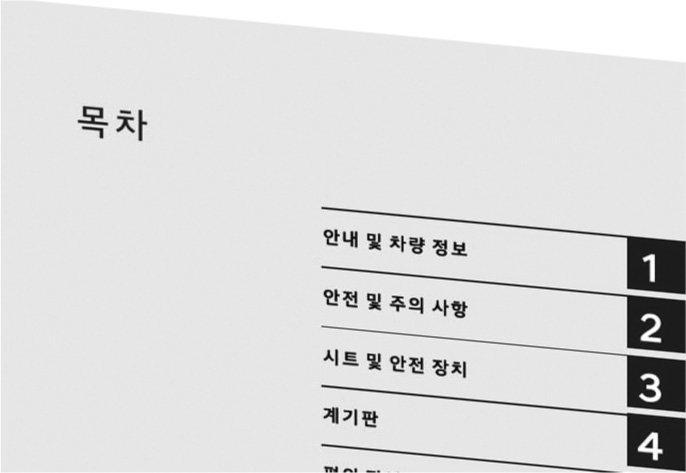

이미지 2: 686 × 473 픽셀


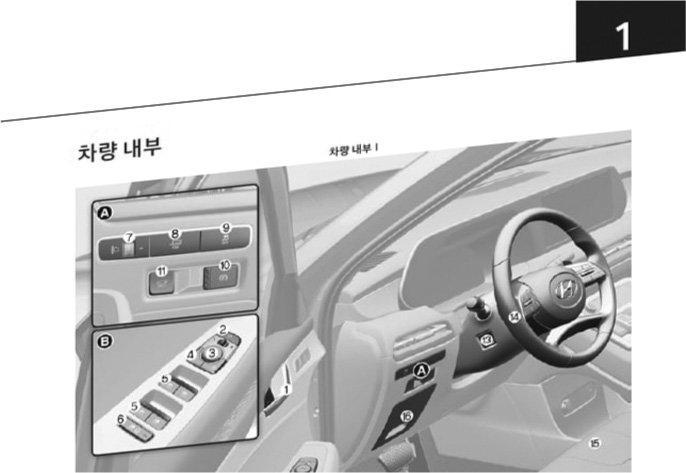

이미지 3: 686 × 473 픽셀


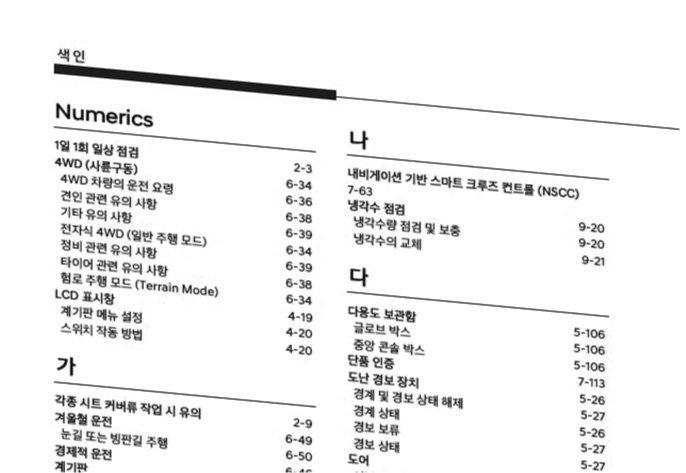

In [5]:
# [프로젝트 추가 기록] PDF 읽기 개념을 싼타페 779쪽 자료에 적용해 글·그림·출처를 조사합니다.
# 추가 이유·한계·수업 근거 전체 목록: src/zzong_santafe_lag/learning_additions.md
from IPython.display import display

# 사람이 세는 2페이지는 파이썬에서는 인덱스 1입니다.
page_2 = reader.pages[1]

# 2페이지에서 추출된 이미지를 차례로 화면에 표시합니다.
for image_number, image in enumerate(page_2.images, start=1):
    print(f"이미지 {image_number}: {image.image.size[0]} × {image.image.size[1]} 픽셀")
    display(image.image)

PDF 44페이지 글자:
온도에 따른 엔진 오일 SAE 점도 분류표
SAE 점도와 사용 온도 범위
온도 (℃)
1.6 T-GDi HEV
안내 및 차량 정보
39
이미지 1: 945 × 71 픽셀


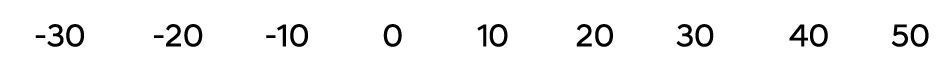

이미지 2: 945 × 71 픽셀


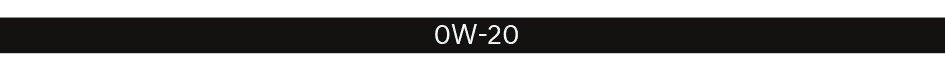

In [6]:
# [프로젝트 추가 기록] PDF 읽기 개념을 싼타페 779쪽 자료에 적용해 글·그림·출처를 조사합니다.
# 추가 이유·한계·수업 근거 전체 목록: src/zzong_santafe_lag/learning_additions.md
from IPython.display import display

# PDF의 44페이지를 선택합니다. 파이썬 인덱스는 0부터 시작합니다.
page_number = 44
page = reader.pages[page_number - 1]

# 그림과 함께 있는 설명 글자를 확인합니다.
page_text = page.extract_text() or ""
print(f"PDF {page_number}페이지 글자:")
print(page_text[:500])

# 페이지에 들어 있는 이미지를 차례로 표시합니다.
for image_number, image in enumerate(page.images, start=1):
    print(f"이미지 {image_number}: {image.image.size[0]} × {image.image.size[1]} 픽셀")
    display(image.image)

In [7]:
# [프로젝트 추가 기록] PDF 읽기 개념을 싼타페 779쪽 자료에 적용해 글·그림·출처를 조사합니다.
# 추가 이유·한계·수업 근거 전체 목록: src/zzong_santafe_lag/learning_additions.md
# PDF의 44페이지에 있는 SAE 점도 표 정보를 한 묶음으로 정리합니다.
pdf_page_number = 44
manual_page_number = 39  # 원본 PDF 아래쪽에 인쇄된 페이지 번호

page = reader.pages[pdf_page_number - 1]

table_record = {
    "pdf_page_number": pdf_page_number,
    "manual_page_number": manual_page_number,
    "heading": "온도에 따른 엔진 오일 SAE 점도 분류표",
    "context_text": page.extract_text() or "",
    "image_parts": [
        {
            "name": image.name,
            "size": image.image.size,
        }
        for image in page.images
    ],
}

# 이미지 두 조각이 같은 표와 페이지에 연결됐는지 확인합니다.
print("PDF 페이지:", table_record["pdf_page_number"])
print("매뉴얼 페이지:", table_record["manual_page_number"])
print("표 이미지 조각:", len(table_record["image_parts"]))
print("이미지 정보:", table_record["image_parts"])

PDF 페이지: 44
매뉴얼 페이지: 39
표 이미지 조각: 2
이미지 정보: [{'name': 'I1.jpg', 'size': (945, 71)}, {'name': 'I2.jpg', 'size': (945, 71)}]


In [8]:
# [프로젝트 추가 기록] PDF 읽기 개념을 싼타페 779쪽 자료에 적용해 글·그림·출처를 조사합니다.
# 추가 이유·한계·수업 근거 전체 목록: src/zzong_santafe_lag/learning_additions.md
# 이미지에서 확인한 내용을 설명 문장으로 기록합니다.
table_record["image_description"] = (
    "온도 눈금은 -30도부터 50도까지 표시되어 있다. "
    "1.6 T-GDi HEV 행에 0W-20이 표시되어 있다."
)

# 표 제목, PDF에서 추출한 글자, 이미지 설명을 하나의 검색 문장으로 합칩니다.
table_record["search_text"] = "\n".join(
    part
    for part in [
        table_record["heading"],
        table_record["context_text"],
        table_record["image_description"],
    ]
    if part.strip()
)

# 검색에 사용될 문장의 앞부분을 확인합니다.
print(table_record["search_text"][:700])

온도에 따른 엔진 오일 SAE 점도 분류표
온도에 따른 엔진 오일 SAE 점도 분류표
SAE 점도와 사용 온도 범위
온도 (℃)
1.6 T-GDi HEV
안내 및 차량 정보
39
온도 눈금은 -30도부터 50도까지 표시되어 있다. 1.6 T-GDi HEV 행에 0W-20이 표시되어 있다.


In [9]:
# [프로젝트 추가 기록] PDF 읽기 개념을 싼타페 779쪽 자료에 적용해 글·그림·출처를 조사합니다.
# 추가 이유·한계·수업 근거 전체 목록: src/zzong_santafe_lag/learning_additions.md
# PDF에서 읽은 글자에는 표 제목이 이미 포함되어 있습니다.
# 그래서 제목을 다시 붙이지 않고 이미지 설명만 이어 붙입니다.
table_record["search_text"] = "\n".join(
    part.strip()
    for part in [
        table_record["context_text"],
        table_record["image_description"],
    ]
    if part.strip()
)

print(table_record["search_text"][:700])

온도에 따른 엔진 오일 SAE 점도 분류표
SAE 점도와 사용 온도 범위
온도 (℃)
1.6 T-GDi HEV
안내 및 차량 정보
39
온도 눈금은 -30도부터 50도까지 표시되어 있다. 1.6 T-GDi HEV 행에 0W-20이 표시되어 있다.


In [10]:
# [프로젝트 추가 기록] PDF 읽기 개념을 싼타페 779쪽 자료에 적용해 글·그림·출처를 조사합니다.
# 추가 이유·한계·수업 근거 전체 목록: src/zzong_santafe_lag/learning_additions.md
# 검색할 글자와 출처 정보, 이미지 조각 정보를 한 묶음으로 정리합니다.
search_record = {
    "content": table_record["search_text"],
    "metadata": {
        "pdf_page_number": table_record["pdf_page_number"],
        "manual_page_number": table_record["manual_page_number"],
        "content_type": "table_with_images",
    },
    "image_parts": table_record["image_parts"],
}

# 각 정보가 제대로 묶였는지 간단히 확인합니다.
print("검색할 글자:", search_record["content"][:300])
print("출처 정보:", search_record["metadata"])
print("이미지 조각:", search_record["image_parts"])

검색할 글자: 온도에 따른 엔진 오일 SAE 점도 분류표
SAE 점도와 사용 온도 범위
온도 (℃)
1.6 T-GDi HEV
안내 및 차량 정보
39
온도 눈금은 -30도부터 50도까지 표시되어 있다. 1.6 T-GDi HEV 행에 0W-20이 표시되어 있다.
출처 정보: {'pdf_page_number': 44, 'manual_page_number': 39, 'content_type': 'table_with_images'}
이미지 조각: [{'name': 'I1.jpg', 'size': (945, 71)}, {'name': 'I2.jpg', 'size': (945, 71)}]


In [11]:
# [프로젝트 추가 기록] PDF 읽기 개념을 싼타페 779쪽 자료에 적용해 글·그림·출처를 조사합니다.
# 추가 이유·한계·수업 근거 전체 목록: src/zzong_santafe_lag/learning_additions.md
# PDF 글자를 한 페이지 단위로 묶습니다.
page_chunks = []

for pdf_page_number, page in enumerate(reader.pages, start=1):
    page_text = (page.extract_text() or "").strip()

    # 글자가 없는 페이지는 검색용 자료에서 제외합니다.
    if not page_text:
        continue

    page_chunks.append({
        "content": page_text,
        "pdf_page_number": pdf_page_number,
    })

print(f"글자 청크 수: {len(page_chunks)}")

# SAE 점도 표가 있는 44페이지 청크도 확인합니다.
page_44_chunk = next(
    chunk for chunk in page_chunks
    if chunk["pdf_page_number"] == 44
)
print("44페이지 글자 앞부분:", page_44_chunk["content"][:200])

글자 청크 수: 777
44페이지 글자 앞부분: 온도에 따른 엔진 오일 SAE 점도 분류표
SAE 점도와 사용 온도 범위
온도 (℃)
1.6 T-GDi HEV
안내 및 차량 정보
39


In [12]:
# [프로젝트 추가 기록] PDF 읽기 개념을 싼타페 779쪽 자료에 적용해 글·그림·출처를 조사합니다.
# 추가 이유·한계·수업 근거 전체 목록: src/zzong_santafe_lag/learning_additions.md
# 주변 3페이지의 첫 부분과 끝 부분을 비교합니다.
for pdf_page_number in [43, 44, 45]:
    page_text = reader.pages[pdf_page_number - 1].extract_text() or ""
    lines = [
        line.strip()
        for line in page_text.splitlines()
        if line.strip()
    ]

    print(f"\nPDF {pdf_page_number}페이지")
    print("처음 3줄:", lines[:3])
    print("마지막 3줄:", lines[-3:])


PDF 43페이지
처음 3줄: ['추천 오일 및 용량', '종류 용량 추천 사양', '연료 67 ℓ 무연 휘발유']
마지막 3줄: ['•', '•', '•']

PDF 44페이지
처음 3줄: ['온도에 따른 엔진 오일 SAE 점도 분류표', 'SAE 점도와 사용 온도 범위', '온도 (℃)']
마지막 3줄: ['1.6 T-GDi HEV', '안내 및 차량 정보', '39']

PDF 45페이지
처음 3줄: ['차대번호 (VIN)', '2C_VINPosition', '차대번호(VIN: Vehicle Identification Number)는 차량 등록, 차량 소유권 유지 등 모든 법적']
마지막 3줄: ['엔진과 차량 실내 사이의 차체 패널에 타각되어 있습니다.', '1', '40']


차대번호 (VIN)
2C_VINPosition
차대번호(VIN: Vehicle Identification Number)는 차량 등록, 차량 소유권 유지 등 모든 법적
인 사항에 사용되는 차량의 고유 번호입니다.
차체에 타각된 차대번호와 차량 등록증에 기록된 차대번호는 일치해야 합니다.
엔진과 차량 실내 사이의 차체 패널에 타각되어 있습니다.
1
40
이미지 1: I1.jpg, 크기 (688, 440)


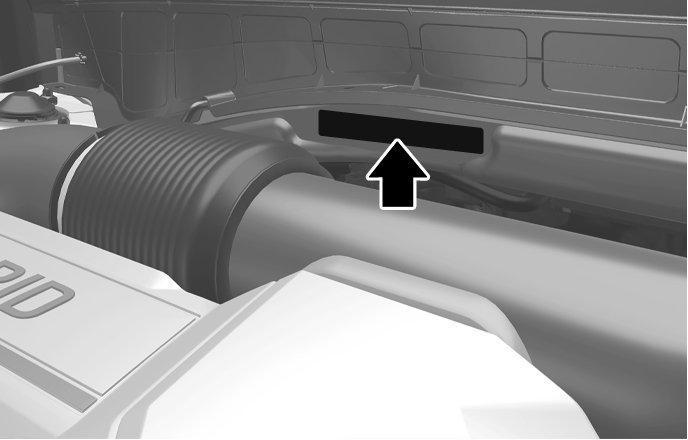

In [13]:
# [프로젝트 추가 기록] PDF 읽기 개념을 싼타페 779쪽 자료에 적용해 글·그림·출처를 조사합니다.
# 추가 이유·한계·수업 근거 전체 목록: src/zzong_santafe_lag/learning_additions.md
from IPython.display import display

# PDF 45페이지를 선택합니다. 파이썬 인덱스는 0부터 시작합니다.
pdf_page_number = 45
page = reader.pages[pdf_page_number - 1]

# 페이지 글자와 포함된 이미지를 확인합니다.
print((page.extract_text() or "")[:300])

for image_number, image in enumerate(page.images, start=1):
    print(f"이미지 {image_number}: {image.name}, 크기 {image.image.size}")
    display(image.image)

In [14]:
# [프로젝트 추가 기록] PDF 읽기 개념을 싼타페 779쪽 자료에 적용해 글·그림·출처를 조사합니다.
# 추가 이유·한계·수업 근거 전체 목록: src/zzong_santafe_lag/learning_additions.md
# PDF 45페이지의 글자와 그림을 가져옵니다.
vin_pdf_page = 45
vin_manual_page = 40
vin_page = reader.pages[vin_pdf_page - 1]

# 이미지 이름처럼 보이는 표시를 본문에서 제외합니다.
vin_text = (vin_page.extract_text() or "").replace("2C_VINPosition", "").strip()

# PDF 설명과 그림을 함께 검색할 수 있도록 그림 설명을 덧붙입니다.
vin_image_description = (
    "그림의 화살표는 엔진과 차량 실내 사이 차체 패널에 있는 "
    "차대번호 타각 위치를 가리킨다."
)

# 글자·페이지 출처·이미지 정보를 한 자료로 묶습니다.
vin_record = {
    "content": f"{vin_text}\n{vin_image_description}",
    "metadata": {
        "pdf_page_number": vin_pdf_page,
        "manual_page_number": vin_manual_page,
        "content_type": "figure_with_text",
    },
    "image_parts": [
        {
            "name": image.name,
            "size": image.image.size,
        }
        for image in vin_page.images
    ],
}

print("출처:", vin_record["metadata"])
print("이미지:", vin_record["image_parts"])
print("검색할 글자:", vin_record["content"][:400])

출처: {'pdf_page_number': 45, 'manual_page_number': 40, 'content_type': 'figure_with_text'}
이미지: [{'name': 'I1.jpg', 'size': (688, 440)}]
검색할 글자: 차대번호 (VIN)

차대번호(VIN: Vehicle Identification Number)는 차량 등록, 차량 소유권 유지 등 모든 법적
인 사항에 사용되는 차량의 고유 번호입니다.
차체에 타각된 차대번호와 차량 등록증에 기록된 차대번호는 일치해야 합니다.
엔진과 차량 실내 사이의 차체 패널에 타각되어 있습니다.
1
40
그림의 화살표는 엔진과 차량 실내 사이 차체 패널에 있는 차대번호 타각 위치를 가리킨다.


In [15]:
# [프로젝트 추가 기록] PDF 읽기 개념을 싼타페 779쪽 자료에 적용해 글·그림·출처를 조사합니다.
# 추가 이유·한계·수업 근거 전체 목록: src/zzong_santafe_lag/learning_additions.md
# PDF에서 추출한 원본 글자는 그대로 보관합니다.
raw_vin_text = vin_page.extract_text() or ""

# 검색할 때 방해되는 이미지 이름만 검색용 글자에서 제외합니다.
vin_search_text = raw_vin_text.replace("2C_VINPosition", "").strip()

# 그림에서 확인한 설명을 검색용 글자에 붙입니다.
vin_search_text = f"{vin_search_text}\n{vin_image_description}".strip()

vin_record["raw_text"] = raw_vin_text
vin_record["search_text"] = vin_search_text

print("원본에는 이미지 이름이 남아 있나요?:", "2C_VINPosition" in vin_record["raw_text"])
print("검색용 글자에 이미지 이름이 있나요?:", "2C_VINPosition" in vin_record["search_text"])
print(vin_record["search_text"][:400])

원본에는 이미지 이름이 남아 있나요?: True
검색용 글자에 이미지 이름이 있나요?: False
차대번호 (VIN)

차대번호(VIN: Vehicle Identification Number)는 차량 등록, 차량 소유권 유지 등 모든 법적
인 사항에 사용되는 차량의 고유 번호입니다.
차체에 타각된 차대번호와 차량 등록증에 기록된 차대번호는 일치해야 합니다.
엔진과 차량 실내 사이의 차체 패널에 타각되어 있습니다.
1
40
그림의 화살표는 엔진과 차량 실내 사이 차체 패널에 있는 차대번호 타각 위치를 가리킨다.


In [16]:
# [프로젝트 추가 기록] PDF 읽기 개념을 싼타페 779쪽 자료에 적용해 글·그림·출처를 조사합니다.
# 추가 이유·한계·수업 근거 전체 목록: src/zzong_santafe_lag/learning_additions.md
# 차대번호 페이지 기록에 어떤 항목이 있는지 확인합니다.
print("기록 항목:", list(vin_record.keys()))

기록 항목: ['content', 'metadata', 'image_parts', 'raw_text', 'search_text']


In [17]:
# [프로젝트 추가 기록] PDF 읽기 개념을 싼타페 779쪽 자료에 적용해 글·그림·출처를 조사합니다.
# 추가 이유·한계·수업 근거 전체 목록: src/zzong_santafe_lag/learning_additions.md
# 세 가지 글자 항목이 서로 어떻게 다른지 짧게 확인합니다.
for name in ("content", "raw_text", "search_text"):
    value = vin_record.get(name, "")
    print(f"\n{name}: {type(value).__name__}, 글자 수={len(value) if isinstance(value, str) else '-'}")

    if isinstance(value, str):
        print(value[:120].replace("\n", " "))

# 페이지 출처와 이미지 개수도 확인합니다.
print("\n출처 정보:", vin_record.get("metadata"))
print("이미지 개수:", len(vin_record.get("image_parts", [])))


content: str, 글자 수=232
차대번호 (VIN)  차대번호(VIN: Vehicle Identification Number)는 차량 등록, 차량 소유권 유지 등 모든 법적 인 사항에 사용되는 차량의 고유 번호입니다. 차체에 타각된 차대번호와 차량

raw_text: str, 글자 수=196
차대번호 (VIN) 2C_VINPosition 차대번호(VIN: Vehicle Identification Number)는 차량 등록, 차량 소유권 유지 등 모든 법적 인 사항에 사용되는 차량의 고유 번호입니다. 차체

search_text: str, 글자 수=232
차대번호 (VIN)  차대번호(VIN: Vehicle Identification Number)는 차량 등록, 차량 소유권 유지 등 모든 법적 인 사항에 사용되는 차량의 고유 번호입니다. 차체에 타각된 차대번호와 차량

출처 정보: {'pdf_page_number': 45, 'manual_page_number': 40, 'content_type': 'figure_with_text'}
이미지 개수: 1


In [18]:
# [프로젝트 추가 기록] PDF 읽기 개념을 싼타페 779쪽 자료에 적용해 글·그림·출처를 조사합니다.
# 추가 이유·한계·수업 근거 전체 목록: src/zzong_santafe_lag/learning_additions.md
# 두 항목의 전체 내용이 정말 같은지 확인합니다.
print("content와 search_text가 완전히 같나요?:", vin_record["content"] == vin_record["search_text"])

content와 search_text가 완전히 같나요?: True


In [19]:
# [프로젝트 추가 기록] PDF 읽기 개념을 싼타페 779쪽 자료에 적용해 글·그림·출처를 조사합니다.
# 추가 이유·한계·수업 근거 전체 목록: src/zzong_santafe_lag/learning_additions.md
from pathlib import Path

# 노트북 코드가 어느 폴더를 기준으로 실행되는지 확인합니다.
current_folder = Path.cwd()
print(f"현재 작업 폴더: {current_folder}")

# 현재 폴더 아래의 data 폴더에서 싼타페 PDF를 찾습니다.
pdf_path = current_folder / "data" / "santafe_hev_manual.pdf"
print(f"찾아볼 파일: {pdf_path}")
print(f"파일이 있나요?: {pdf_path.exists()}")

현재 작업 폴더: c:\mle-02-p1-team1\notebooks
찾아볼 파일: c:\mle-02-p1-team1\notebooks\data\santafe_hev_manual.pdf
파일이 있나요?: False


In [20]:
# [프로젝트 추가 기록] PDF 읽기 개념을 싼타페 779쪽 자료에 적용해 글·그림·출처를 조사합니다.
# 추가 이유·한계·수업 근거 전체 목록: src/zzong_santafe_lag/learning_additions.md
from pathlib import Path

# 현재 폴더(notebooks)의 상위 폴더를 프로젝트 폴더로 봅니다.
project_folder = Path.cwd().parent

# 프로젝트 폴더 아래 data 폴더에서 PDF를 찾습니다.
pdf_path = project_folder / "data" / "santafe_hev_manual.pdf"

print("찾는 위치:", pdf_path)
print("파일이 있나요?:", pdf_path.exists())

찾는 위치: c:\mle-02-p1-team1\data\santafe_hev_manual.pdf
파일이 있나요?: True


In [21]:
# [프로젝트 추가 기록] PDF 읽기 개념을 싼타페 779쪽 자료에 적용해 글·그림·출처를 조사합니다.
# 추가 이유·한계·수업 근거 전체 목록: src/zzong_santafe_lag/learning_additions.md
# 이미지마다 어떤 정보가 기록되어 있는지 확인합니다.
for 번호, 이미지 in enumerate(vin_record["image_parts"], start=1):
    print(f"\n이미지 {번호} 자료형:", type(이미지).__name__)

    # 이미지 정보가 딕셔너리라면 항목 이름을 확인합니다.
    if isinstance(이미지, dict):
        print("기록된 항목:", list(이미지.keys()))

        # 파일 이름이나 크기처럼 확인에 필요한 정보만 출력합니다.
        for 항목 in ("name", "filename", "path", "size", "width", "height"):
            if 항목 in 이미지:
                print(f"{항목}:", 이미지[항목])


이미지 1 자료형: dict
기록된 항목: ['name', 'size']
name: I1.jpg
size: (688, 440)


In [22]:
# [프로젝트 추가 기록] PDF 읽기 개념을 싼타페 779쪽 자료에 적용해 글·그림·출처를 조사합니다.
# 추가 이유·한계·수업 근거 전체 목록: src/zzong_santafe_lag/learning_additions.md
# 이미지가 이미 저장되어 있는지 프로젝트의 data와 notebooks 폴더에서 찾습니다.
search_folders = [
    project_folder / "data",
    project_folder / "notebooks",
]

found_images = []

for folder in search_folders:
    if folder.exists():
        found_images.extend(folder.rglob("I1.jpg"))

print("찾은 I1.jpg 파일 수:", len(found_images))

for image_path in found_images:
    print(image_path)

찾은 I1.jpg 파일 수: 0


In [23]:
# [프로젝트 추가 기록] PDF 읽기 개념을 싼타페 779쪽 자료에 적용해 글·그림·출처를 조사합니다.
# 추가 이유·한계·수업 근거 전체 목록: src/zzong_santafe_lag/learning_additions.md
from pathlib import Path
from pypdf import PdfReader

# 노트북 폴더에서 실행 중이면 한 단계 위를 프로젝트 폴더로 사용합니다.
현재_폴더 = Path.cwd()
프로젝트_폴더 = (
    현재_폴더.parent
    if 현재_폴더.name.lower() == "notebooks"
    else 현재_폴더
)

# 원본 PDF 파일을 엽니다.
pdf_path = 프로젝트_폴더 / "data" / "santafe_hev_manual.pdf"
reader = PdfReader(str(pdf_path))

# PDF 45쪽은 파이썬에서 0부터 세므로 44번 위치입니다.
pdf_페이지_번호 = 45
페이지 = reader.pages[pdf_페이지_번호 - 1]
이미지들 = 페이지.images

# 승인한 개인 작업 폴더를 준비합니다.
저장_폴더 = (
    프로젝트_폴더
    / "data"
    / "zzong_santafe_lag"
    / "images"
    / "pdf_page_45"
)
저장_폴더.mkdir(parents=True, exist_ok=True)

# 페이지 안의 이미지를 I1.jpg 같은 이름으로 저장합니다.
for 번호, 이미지 in enumerate(이미지들, start=1):
    확장자 = Path(이미지.name).suffix.lower() or ".png"
    저장_경로 = 저장_폴더 / f"I{번호}{확장자}"

    if 저장_경로.exists():
        print("이미 있어 건너뜀:", 저장_경로)
    else:
        이미지.image.save(저장_경로)
        print("저장 완료:", 저장_경로, "| 이미지 크기:", 이미지.image.size)

print("PDF 45쪽 이미지 개수:", len(이미지들))

저장 완료: c:\mle-02-p1-team1\data\zzong_santafe_lag\images\pdf_page_45\I1.jpg | 이미지 크기: (688, 440)
PDF 45쪽 이미지 개수: 1


In [24]:
# [프로젝트 추가 기록] PDF 읽기 개념을 싼타페 779쪽 자료에 적용해 글·그림·출처를 조사합니다.
# 추가 이유·한계·수업 근거 전체 목록: src/zzong_santafe_lag/learning_additions.md
from pathlib import Path

# 현재 위치에서 프로젝트 폴더를 찾습니다.
현재_폴더 = Path.cwd()
프로젝트_폴더 = (
    현재_폴더.parent
    if 현재_폴더.name.lower() == "notebooks"
    else 현재_폴더
)

# 저장한 이미지 파일의 경로를 만듭니다.
이미지_경로 = (
    프로젝트_폴더
    / "data"
    / "zzong_santafe_lag"
    / "images"
    / "pdf_page_45"
    / "I1.jpg"
)

# 이미지 파일이 있는지 확인한 뒤 기록에 경로를 연결합니다.
if not 이미지_경로.exists():
    raise FileNotFoundError(f"이미지 파일을 찾을 수 없습니다: {이미지_경로}")

vin_record["image_parts"][0]["local_path"] = (
    이미지_경로.relative_to(프로젝트_폴더).as_posix()
)

print("이미지 연결 경로:", vin_record["image_parts"][0]["local_path"])

이미지 연결 경로: data/zzong_santafe_lag/images/pdf_page_45/I1.jpg


In [25]:
# [프로젝트 추가 기록] PDF 읽기 개념을 싼타페 779쪽 자료에 적용해 글·그림·출처를 조사합니다.
# 추가 이유·한계·수업 근거 전체 목록: src/zzong_santafe_lag/learning_additions.md
from pathlib import Path
from pypdf import PdfReader

# 노트북 폴더에서 실행하면 한 단계 위를 프로젝트 폴더로 사용합니다.
현재_폴더 = Path.cwd()
프로젝트_폴더 = (
    현재_폴더.parent
    if 현재_폴더.name.lower() == "notebooks"
    else 현재_폴더
)

# 산타페 설명서 PDF를 엽니다.
pdf_path = 프로젝트_폴더 / "data" / "santafe_hev_manual.pdf"
reader = PdfReader(str(pdf_path))

# PDF 44쪽은 파이썬에서 0부터 세므로 43번 위치입니다.
pdf_페이지_번호 = 44
페이지 = reader.pages[pdf_페이지_번호 - 1]
이미지들 = 페이지.images

# 예상한 이미지 2개가 맞는지 먼저 확인합니다.
print("PDF 44쪽 이미지 개수:", len(이미지들))

if len(이미지들) != 2:
    raise ValueError("PDF 44쪽 이미지가 예상한 2개가 아닙니다. 결과를 확인해 주세요.")

# 승인한 개인 폴더를 준비합니다.
저장_폴더 = (
    프로젝트_폴더
    / "data"
    / "zzong_santafe_lag"
    / "images"
    / "pdf_page_44"
)
저장_폴더.mkdir(parents=True, exist_ok=True)

# 표를 이루는 이미지 두 조각을 I1, I2 이름으로 저장합니다.
for 번호, 이미지 in enumerate(이미지들, start=1):
    확장자 = Path(이미지.name).suffix.lower() or ".png"
    저장_경로 = 저장_폴더 / f"I{번호}{확장자}"

    if 저장_경로.exists():
        print("이미 있어 건너뜀:", 저장_경로)
    else:
        이미지.image.save(저장_경로)
        print(
            "저장 완료:",
            저장_경로,
            "| 이미지 크기:",
            이미지.image.size,
        )

PDF 44쪽 이미지 개수: 2
저장 완료: c:\mle-02-p1-team1\data\zzong_santafe_lag\images\pdf_page_44\I1.jpg | 이미지 크기: (945, 71)
저장 완료: c:\mle-02-p1-team1\data\zzong_santafe_lag\images\pdf_page_44\I2.jpg | 이미지 크기: (945, 71)


In [26]:
# [프로젝트 추가 기록] PDF 읽기 개념을 싼타페 779쪽 자료에 적용해 글·그림·출처를 조사합니다.
# 추가 이유·한계·수업 근거 전체 목록: src/zzong_santafe_lag/learning_additions.md
# 노트북에 만들어 둔 record 변수의 이름만 확인합니다.
print([이름 for 이름 in globals() if "record" in 이름.lower()])

['table_record', 'search_record', 'vin_record']


In [27]:
# [프로젝트 추가 기록] PDF 읽기 개념을 싼타페 779쪽 자료에 적용해 글·그림·출처를 조사합니다.
# 추가 이유·한계·수업 근거 전체 목록: src/zzong_santafe_lag/learning_additions.md
# PDF 44쪽 표 기록이 어느 변수인지 출처와 글자 앞부분으로 확인합니다.
for 변수_이름 in ("table_record", "search_record"):
    기록 = globals()[변수_이름]

    print(f"\n변수 이름: {변수_이름}")
    print("출처 정보:", 기록.get("metadata"))
    print("글자 앞부분:", 기록.get("content", "")[:80])


변수 이름: table_record
출처 정보: None
글자 앞부분: 

변수 이름: search_record
출처 정보: {'pdf_page_number': 44, 'manual_page_number': 39, 'content_type': 'table_with_images'}
글자 앞부분: 온도에 따른 엔진 오일 SAE 점도 분류표
SAE 점도와 사용 온도 범위
온도 (℃)
1.6 T-GDi HEV
안내 및 차량 정보
39
온도 눈


In [28]:
# [프로젝트 추가 기록] PDF 읽기 개념을 싼타페 779쪽 자료에 적용해 글·그림·출처를 조사합니다.
# 추가 이유·한계·수업 근거 전체 목록: src/zzong_santafe_lag/learning_additions.md
from pathlib import Path

# 프로젝트 폴더와 PDF 44쪽 이미지 폴더를 찾습니다.
현재_폴더 = Path.cwd()
프로젝트_폴더 = (
    현재_폴더.parent
    if 현재_폴더.name.lower() == "notebooks"
    else 현재_폴더
)
이미지_폴더 = (
    프로젝트_폴더
    / "data"
    / "zzong_santafe_lag"
    / "images"
    / "pdf_page_44"
)

# PDF 44쪽 기록에 이미지가 2개인지 확인합니다.
이미지_기록들 = search_record["image_parts"]

if len(이미지_기록들) != 2:
    raise ValueError("search_record의 이미지 개수가 예상한 2개와 다릅니다.")

# 이미지 이름에 해당하는 파일을 찾아 경로를 기록합니다.
for 이미지_기록 in 이미지_기록들:
    이미지_이름 = Path(이미지_기록["name"]).name
    이미지_경로 = 이미지_폴더 / 이미지_이름

    if not 이미지_경로.exists():
        raise FileNotFoundError(f"이미지 파일을 찾을 수 없습니다: {이미지_경로}")

    이미지_기록["local_path"] = (
        이미지_경로.relative_to(프로젝트_폴더).as_posix()
    )

# 연결 결과를 확인합니다.
for 이미지_기록 in 이미지_기록들:
    print(이미지_기록)

{'name': 'I1.jpg', 'size': (945, 71), 'local_path': 'data/zzong_santafe_lag/images/pdf_page_44/I1.jpg'}
{'name': 'I2.jpg', 'size': (945, 71), 'local_path': 'data/zzong_santafe_lag/images/pdf_page_44/I2.jpg'}


In [29]:
# [프로젝트 추가 기록] PDF 읽기 개념을 싼타페 779쪽 자료에 적용해 글·그림·출처를 조사합니다.
# 추가 이유·한계·수업 근거 전체 목록: src/zzong_santafe_lag/learning_additions.md
# PDF 44쪽 표와 PDF 45쪽 차대번호 기록의 항목 구성을 비교합니다.
for 설명, 기록 in (
    ("PDF 44쪽 표", search_record),
    ("PDF 45쪽 차대번호", vin_record),
):
    print(f"\n{설명}")
    print("기록 항목:", list(기록.keys()))
    print("출처 정보:", 기록.get("metadata"))
    print("이미지 개수:", len(기록.get("image_parts", [])))


PDF 44쪽 표
기록 항목: ['content', 'metadata', 'image_parts']
출처 정보: {'pdf_page_number': 44, 'manual_page_number': 39, 'content_type': 'table_with_images'}
이미지 개수: 2

PDF 45쪽 차대번호
기록 항목: ['content', 'metadata', 'image_parts', 'raw_text', 'search_text']
출처 정보: {'pdf_page_number': 45, 'manual_page_number': 40, 'content_type': 'figure_with_text'}
이미지 개수: 1
